# Comparing `SurfaceGarabedianQuantiles` vs `SurfaceGarabedianLinear`

Both classes in [`alpha_opt/surface/garabedian.py`](../alpha_opt/surface/garabedian.py) represent a stellarator
boundary as a `SurfaceGarabedian` whose degrees of freedom (dofs) live in `[0, 1]`, with `(m,n)=(0,0)` fixed to the
minor radius and `(m,n)=(1,0)` fixed to the major radius. They load the same weighted training dataset
(`data`, `weights`, `ms`, `ns` in an HDF5 file) and select/sort the same rectangular `(m, n)` mode grid. The **only**
difference is how a dof value in `[0, 1]` is mapped to the physical Garabedian coefficient for that mode:

- **`SurfaceGarabedianQuantiles`** uses a `WeightedQuantileTransformer`: dof -> physical value is the inverse of the
  *weighted empirical CDF* of that mode across the training data. `x=0.5` maps to the weighted median.
- **`SurfaceGarabedianLinear`** uses a straight line between the 5th and 95th percentile of that mode
  (`lower + x * (upper - lower)`). `x=0.5` maps to the midpoint of that range, not necessarily the median.

This notebook builds both surfaces from the same training file and compares:
1. Whether `SurfaceGarabedianLinear`'s `[p5, p95]` band is actually weighted, as its docstring claims.
2. The dof -> physical-value mapping curve, mode by mode.
3. Whether uniform sampling of dofs reproduces the training distribution under each parameterization.
4. What the resulting boundary shapes look like.

In [1]:
import os
import importlib.util
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Load garabedian.py (and constants.py) directly, bypassing alpha_opt/__init__.py.
# alpha_opt/__init__.py eagerly imports alpha_opt.visualization, which calls
# matplotlib.use("Agg") at module scope -- that clobbers the notebook's inline
# backend so plt.show() stops rendering figures. Loading the submodule files
# directly avoids running __init__.py (and its matplotlib.use("Agg") side effect)
# at all.
REPO_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(REPO_ROOT, "data")

def _load_module(name, relpath):
    spec = importlib.util.spec_from_file_location(name, os.path.join(REPO_ROOT, relpath))
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

garabedian = _load_module("garabedian", "alpha_opt/surface/garabedian.py")
constants = _load_module("alpha_opt_constants", "alpha_opt/constants.py")

SurfaceGarabedianQuantiles = garabedian.SurfaceGarabedianQuantiles
SurfaceGarabedianLinear = garabedian.SurfaceGarabedianLinear
ARIES_CS_MINOR_RADIUS = constants.ARIES_CS_MINOR_RADIUS

# Categorical colors, consistent across all plots below
BLUE = "#2a78d6"   # SurfaceGarabedianQuantiles
RED = "#e34948"    # SurfaceGarabedianLinear
GRAY = "#8a8a86"   # training data reference

## Setup

Same configuration `usable_space.measure_usable_space` uses for the Garabedian parameterization
(`allNfp` dataset, `nfp=4`, `mpol=ntor=2`, ARIES-CS-scale minor radius, aspect ratio 6). `exact_radii` is left at its
default (`False`) here so the raw per-mode parameterization can be compared without the aspect-ratio root-solve
correction mixing in.

In [15]:
nfp = 4
mpol = 2
ntor = 2
aspect_ratio = 6.0
minor_radius = 3.1 / aspect_ratio**0.38
major_radius = minor_radius * aspect_ratio

h5_filepath = os.path.join(DATA_DIR, "20260402-01_prepare_weighted_data_nfpAtLeast3_Garabedian.h5")

surface_q = SurfaceGarabedianQuantiles(
    nfp=nfp, major_radius=major_radius, minor_radius=minor_radius, mpol=mpol, ntor=ntor, filename=h5_filepath,
)
surface_l = SurfaceGarabedianLinear(
    nfp=nfp, major_radius=major_radius, minor_radius=minor_radius, mpol=mpol, ntor=ntor, filename=h5_filepath,
)

# Both classes should select/sort the exact same variable (m, n) modes from the same file
assert np.array_equal(surface_q.ms_variable, surface_l.ms_variable)
assert np.array_equal(surface_q.ns_variable, surface_l.ns_variable)

n_dofs = len(surface_q.x)
print(f"{n_dofs} variable Garabedian modes (dofs) for mpol={mpol}, ntor={ntor}")

Full data shape: (151, 121)
Number of configurations: 151
Number of Garabedian modes in file: 121
Selected total modes: 25
Variable modes (number of dofs): 23
Full data shape: (151, 121)
Number of configurations: 151
Number of Garabedian modes in file: 121
Selected total modes: 25
Variable modes (number of dofs): 23
23 variable Garabedian modes (dofs) for mpol=2, ntor=2


In [30]:
with h5py.File(h5_filepath, "r") as f:
    data_all = f["data"][()]
    weights = f["weights"][()]
    ms_all = f["ms"][()]
    ns_all = f["ns"][()]

In [37]:
weights

array([0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.03225806, 0.03225806, 0.03225806, 0.03225806,
       0.03225806, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086957,
       0.01086957, 0.01086957, 0.01086957, 0.01086957, 0.01086

## 1. Reload the raw training data

Neither class exposes the masked/sorted `data_variable` array it fits on, so we replicate the same masking + sorting
logic here to inspect it directly (in particular, the sample `weights`).

In [24]:
def load_variable_mode_data(filename, mpol, ntor):
    """Replicates the mode selection/sorting in SurfaceGarabedianQuantiles/Linear.__init__."""
    with h5py.File(filename, "r") as f:
        data_all = f["data"][()]
        weights = f["weights"][()]
        ms_all = f["ms"][()]
        ns_all = f["ns"][()]
        source_counts = {
            "Kappel": int(f["n_Kappel"][()]),
            "QUASR": int(f["n_QUASR"][()]),
            "constellaration": int(f["n_constellaration"][()]),
        }

    mask_keep = (
        (ms_all >= -mpol + 1) & (ms_all <= mpol + 1)
        & (ns_all >= -ntor) & (ns_all <= ntor)
    )
    ms_sel, ns_sel, data_sel = ms_all[mask_keep], ns_all[mask_keep], data_all[:, mask_keep]
    sort_idx = np.lexsort((ns_sel, ms_sel))
    ms_sel, ns_sel, data_sel = ms_sel[sort_idx], ns_sel[sort_idx], data_sel[:, sort_idx]

    fixed_mask = ((ms_sel == 0) & (ns_sel == 0)) | ((ms_sel == 1) & (ns_sel == 0))
    variable_mask = ~fixed_mask
    return ms_sel[variable_mask], ns_sel[variable_mask], data_sel[:, variable_mask], weights, source_counts


ms_variable, ns_variable, data_variable, weights, source_counts = load_variable_mode_data(h5_filepath, mpol, ntor)
assert np.array_equal(ms_variable, surface_q.ms_variable)

# Each source's rows all carry weight 1/(number of configs from that source) -- see if the
# unique weight values match 1/source_counts, so we can label plots with source names instead
# of raw weight values.
unique_weights = np.unique(weights)
weight_to_source = {}
for name, count in source_counts.items():
    match = unique_weights[np.isclose(unique_weights, 1.0 / count)]
    if len(match) == 1:
        weight_to_source[match[0]] = name

print(f"Training configurations: {data_variable.shape[0]}, variable modes: {data_variable.shape[1]}")
print(f"source counts: {source_counts}")
print(f"weight -> source: {weight_to_source}")

Training configurations: 151, variable modes: 23
source counts: {'Kappel': 31, 'QUASR': 92, 'constellaration': 28}
weight -> source: {np.float64(0.03225806451612903): 'Kappel', np.float64(0.010869565217391304): 'QUASR', np.float64(0.03571428571428571): 'constellaration'}


### Raw data points, every variable mode

One small subplot per variable `(m, n)` mode, showing every training configuration's raw coefficient value (`data_variable`, not yet passed through either transform). Points are colored by their sample `weight` — since there are only a handful of distinct weight values (one per data source), this doubles as a rough view of which source each configuration came from.

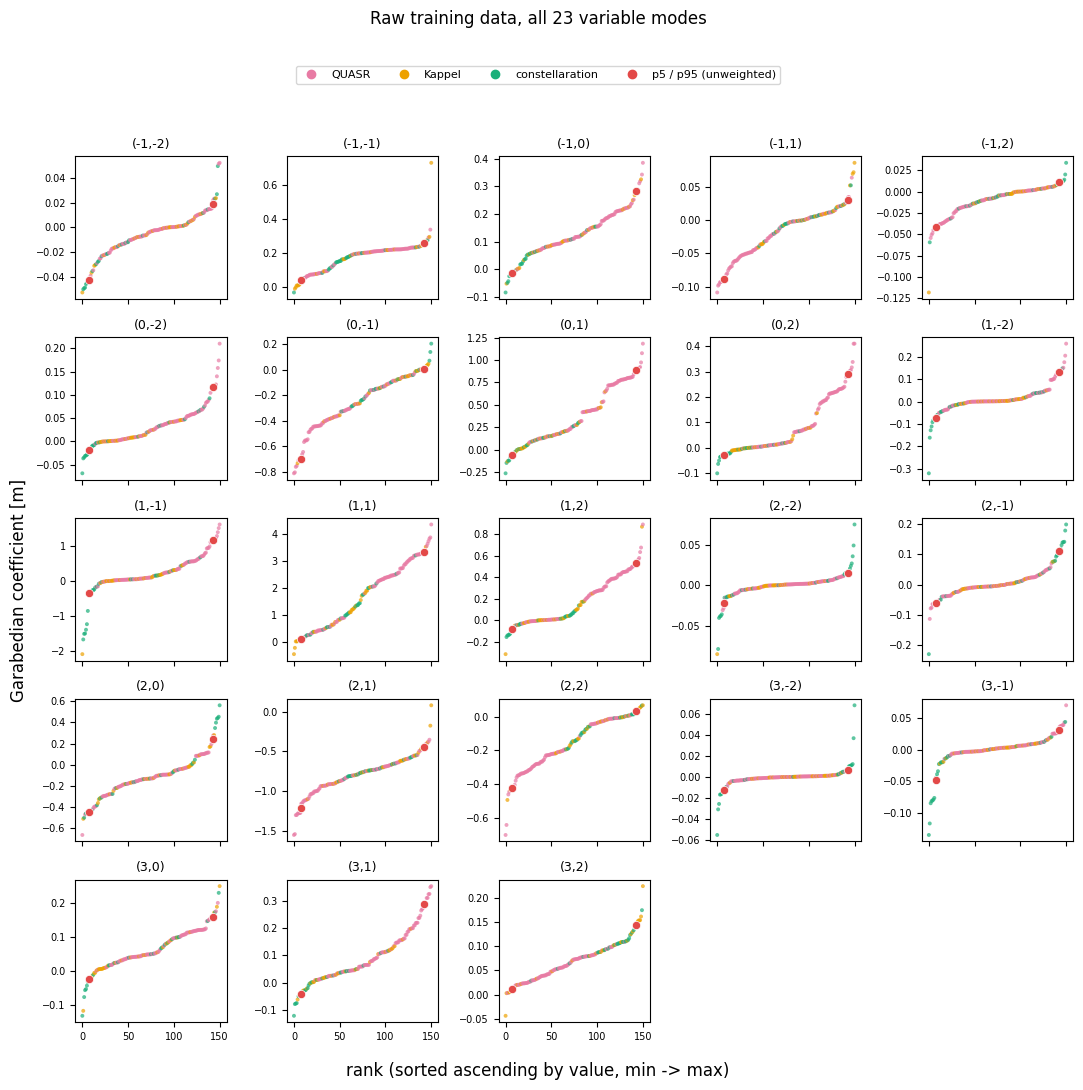

In [26]:
n_modes = data_variable.shape[1]
n_configs = data_variable.shape[0]
ncols = int(np.ceil(np.sqrt(n_modes)))
nrows = int(np.ceil(n_modes / ncols))

# One color per distinct sample weight (i.e. per data source)
palette = ["#e87ba4", "#eda100", "#1baf7a", "#4a3aa7", "#eb6834", "#008300", "#e34948"]
weight_colors = dict(zip(unique_weights, palette))
point_colors = np.array([weight_colors[w] for w in weights])

# surface_l.lower/upper are the (unweighted) 5th/95th percentiles SurfaceGarabedianLinear uses
# for its [0, 1] mapping. Under np.percentile's default linear-interpolation convention, the
# p-th percentile of a sorted array of N points sits at rank p/100 * (N - 1).
x_p5, x_p95 = 0.05 * (n_configs - 1), 0.95 * (n_configs - 1)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.0 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for j in range(n_modes):
    ax = axes[j]
    # Sort ascending so the x axis runs from the smallest to the largest value for this mode,
    # rather than following the (arbitrary) training-configuration order.
    order = np.argsort(data_variable[:, j])
    ax.scatter(
        np.arange(n_configs), data_variable[order, j] * minor_radius,
        c=point_colors[order], s=8, alpha=0.7, linewidths=0,
    )
    ax.scatter(
        [x_p5, x_p95], [surface_l.lower[j] * minor_radius, surface_l.upper[j] * minor_radius],
        color=RED, s=35, zorder=5, edgecolors="white", linewidths=0.5,
    )

    m, n = int(ms_variable[j]), int(ns_variable[j])
    ax.set_title(f"({m},{n})", fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[n_modes:]:
    ax.axis("off")

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=c, label=weight_to_source.get(w, f"weight={w:.4f}"))
    for w, c in weight_colors.items()
]
handles.append(plt.Line2D([], [], marker="o", linestyle="", color=RED, label="p5 / p95 (unweighted)"))
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 1.03), fontsize=8)

fig.supxlabel("rank (sorted ascending by value, min -> max)")
fig.supylabel("Garabedian coefficient [m]")
fig.suptitle(f"Raw training data, all {n_modes} variable modes", y=1.08)
plt.tight_layout()
plt.show()

### Original values vs. each transform, mode by mode

One row per variable mode, three columns:
1. **Original values** — same sorted-by-rank scatter as above, with the (unweighted) p5/p95 marked in red.
2. **Linear transform** — x is the original value, y is `SurfaceGarabedianLinear`'s dof output `(x - lower) / (upper - lower)`. The red line is the transform itself (a straight line by construction, anchored at `(lower, 0)` and `(upper, 1)`); the dots are where the actual training points land — note they can fall below 0 or above 1 since only 90% of the data lies inside `[p5, p95]`.
3. **Quantile transform** — x is the original value, y is `SurfaceGarabedianQuantiles`'s dof output (the weighted-quantile inverse-CDF). The blue curve is the transform itself; unlike the linear case it's monotonic but non-affine, so it always maps into `[0, 1]` and stretches/compresses to match the local data density.

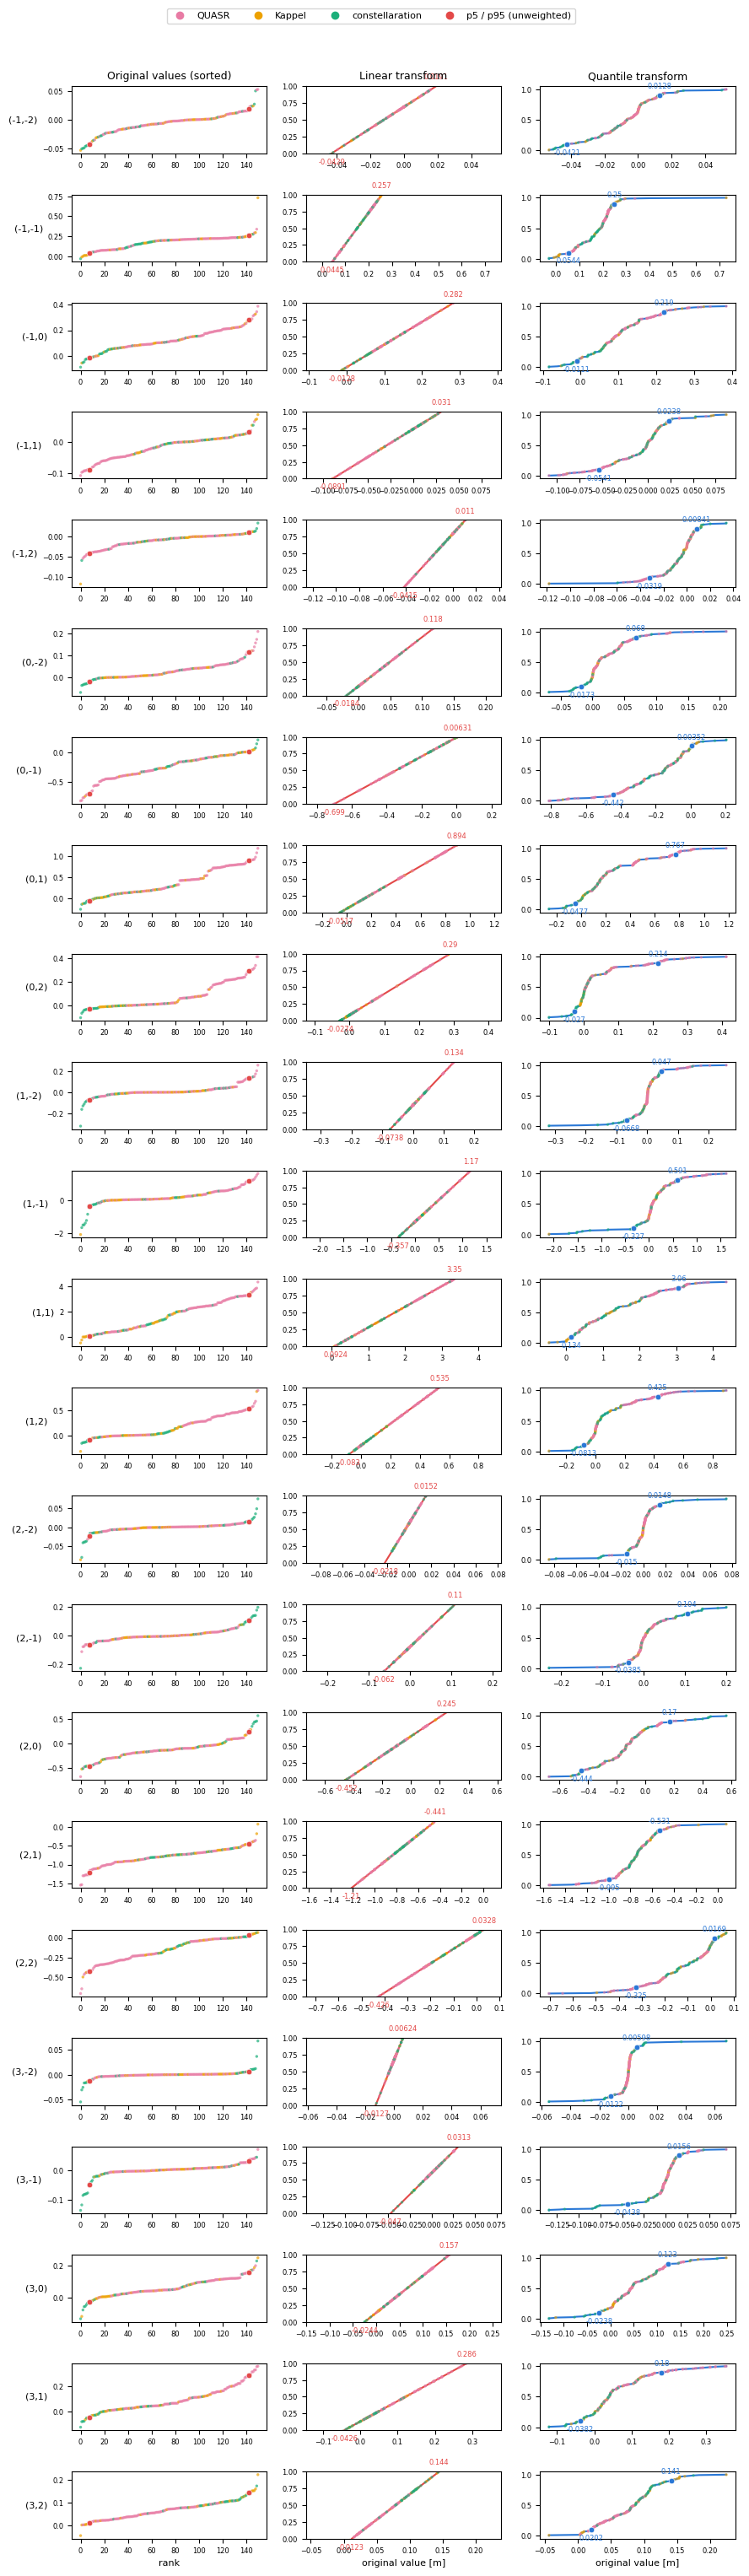

In [38]:
n_modes = data_variable.shape[1]
n_configs = data_variable.shape[0]
x_p5, x_p95 = 0.05 * (n_configs - 1), 0.95 * (n_configs - 1)

# Forward quantile-transform of every training point, computed once (not per row)
q_transformed_all = surface_q.transformer.transform(data_variable)

fig, axes = plt.subplots(n_modes, 3, figsize=(9, 1.3 * n_modes))

for j in range(n_modes):
    m, n = int(ms_variable[j]), int(ns_variable[j])
    orig_vals = data_variable[:, j] * minor_radius
    lower_j, upper_j = surface_l.lower[j] * minor_radius, surface_l.upper[j] * minor_radius

    # --- Column 1: original values, sorted ascending (same as the raw-data-points cell) ---
    ax = axes[j, 0]
    order = np.argsort(data_variable[:, j])
    ax.scatter(np.arange(n_configs), orig_vals[order], c=point_colors[order], s=6, alpha=0.7, linewidths=0)
    ax.scatter(
        [x_p5, x_p95], [lower_j, upper_j],
        color=RED, s=22, zorder=5, edgecolors="white", linewidths=0.4,
    )
    ax.set_ylabel(f"({m},{n})", fontsize=8, rotation=0, ha="right", va="center")
    ax.tick_params(labelsize=6)

    # --- Column 2: linear transform -- x = original value, y = dof in [0, 1] ---
    ax = axes[j, 1]
    ax.plot([lower_j, upper_j], [0.0, 1.0], color=RED, lw=1.5, zorder=1)
    y_linear = (orig_vals - lower_j) / (upper_j - lower_j)
    ax.scatter(orig_vals, y_linear, c=point_colors, s=6, alpha=0.6, linewidths=0, zorder=2)
    ax.axhline(0, color="0.85", lw=0.5, zorder=0)
    ax.axhline(1, color="0.85", lw=0.5, zorder=0)
    # Original-space x values that map to the transformed 0 and 1
    ax.annotate(
        f"{lower_j:.3g}", (lower_j, 0.0), textcoords="offset points", xytext=(0, -9),
        ha="center", fontsize=6, color=RED,
    )
    ax.annotate(
        f"{upper_j:.3g}", (upper_j, 1.0), textcoords="offset points", xytext=(0, 6),
        ha="center", fontsize=6, color=RED,
    )
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=6)

    # --- Column 3: quantile transform -- x = original value, y = dof in [0, 1] ---
    ax = axes[j, 2]
    x_curve = surface_q.transformer.quantiles_[:, j] * minor_radius
    y_curve = surface_q.transformer.references_
    ax.plot(x_curve, y_curve, color=BLUE, lw=1.5, zorder=1)
    ax.scatter(orig_vals, q_transformed_all[:, j], c=point_colors, s=6, alpha=0.6, linewidths=0, zorder=2)

    # Original-space x values that map to the transformed 0.1 and 0.9
    x_q10 = np.interp(0.1, y_curve, x_curve)
    x_q90 = np.interp(0.9, y_curve, x_curve)
    ax.scatter(
        [x_q10, x_q90], [0.1, 0.9],
        color=BLUE, s=22, zorder=5, edgecolors="white", linewidths=0.4,
    )
    ax.annotate(
        f"{x_q10:.3g}", (x_q10, 0.1), textcoords="offset points", xytext=(0, -9),
        ha="center", fontsize=6, color=BLUE,
    )
    ax.annotate(
        f"{x_q90:.3g}", (x_q90, 0.9), textcoords="offset points", xytext=(0, 6),
        ha="center", fontsize=6, color=BLUE,
    )
    ax.tick_params(labelsize=6)

axes[0, 0].set_title("Original values (sorted)", fontsize=9)
axes[0, 1].set_title("Linear transform", fontsize=9)
axes[0, 2].set_title("Quantile transform", fontsize=9)
axes[-1, 0].set_xlabel("rank", fontsize=8)
axes[-1, 1].set_xlabel("original value [m]", fontsize=8)
axes[-1, 2].set_xlabel("original value [m]", fontsize=8)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=c, label=weight_to_source.get(w, f"weight={w:.4f}"))
    for w, c in weight_colors.items()
]
handles.append(plt.Line2D([], [], marker="o", linestyle="", color=RED, label="p5 / p95 (unweighted)"))
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 1.0 + 0.5 / n_modes), fontsize=8)

plt.tight_layout()
plt.show()

## 6. PCA on the full transformed dof space

`SurfaceGarabedianQuantiles`/`Linear` transform each mode independently, one at a time — neither accounts for
correlations *between* modes. To see how much cross-mode correlation is left after each per-mode transform, run
(unweighted) PCA across the full `n_modes`-dimensional space produced by each parameterization and compare the
explained-variance curves. If the modes were fully decorrelated, all `n_modes` components would be needed and each
would explain roughly `1/n_modes` of the variance; strong leftover correlations show up as a few components
explaining most of the variance.

In [39]:
from sklearn.decomposition import PCA

linear_transformed_all = (data_variable - surface_l.lower) / (surface_l.upper - surface_l.lower)
quantile_transformed_all = surface_q.transformer.transform(data_variable)

pca_linear = PCA().fit(linear_transformed_all)
pca_quantile = PCA().fit(quantile_transformed_all)

cum_linear = np.cumsum(pca_linear.explained_variance_ratio_)
cum_quantile = np.cumsum(pca_quantile.explained_variance_ratio_)

n90_linear = np.searchsorted(cum_linear, 0.90) + 1
n90_quantile = np.searchsorted(cum_quantile, 0.90) + 1

print(f"Linear-transformed dof space:   {n90_linear}/{n_modes} components needed for 90% variance")
print(f"Quantile-transformed dof space: {n90_quantile}/{n_modes} components needed for 90% variance")

Linear-transformed dof space:   8/23 components needed for 90% variance
Quantile-transformed dof space: 9/23 components needed for 90% variance


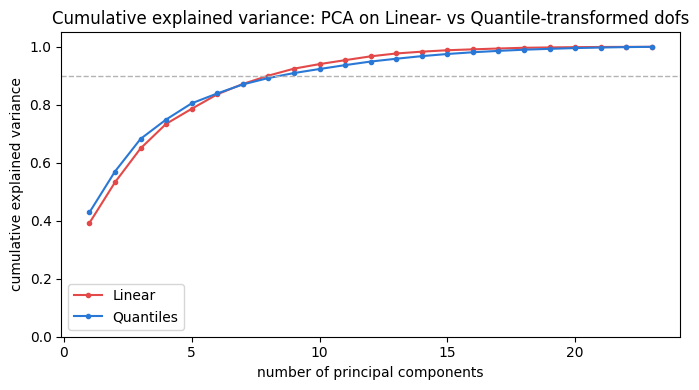

In [40]:
fig, ax = plt.subplots(figsize=(7, 4))
components = np.arange(1, n_modes + 1)
ax.plot(components, cum_linear, color=RED, marker="o", markersize=3, label="Linear")
ax.plot(components, cum_quantile, color=BLUE, marker="o", markersize=3, label="Quantiles")
ax.axhline(0.9, color="0.7", lw=1, linestyle="--")
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Cumulative explained variance: PCA on Linear- vs Quantile-transformed dofs")
plt.tight_layout()
plt.show()

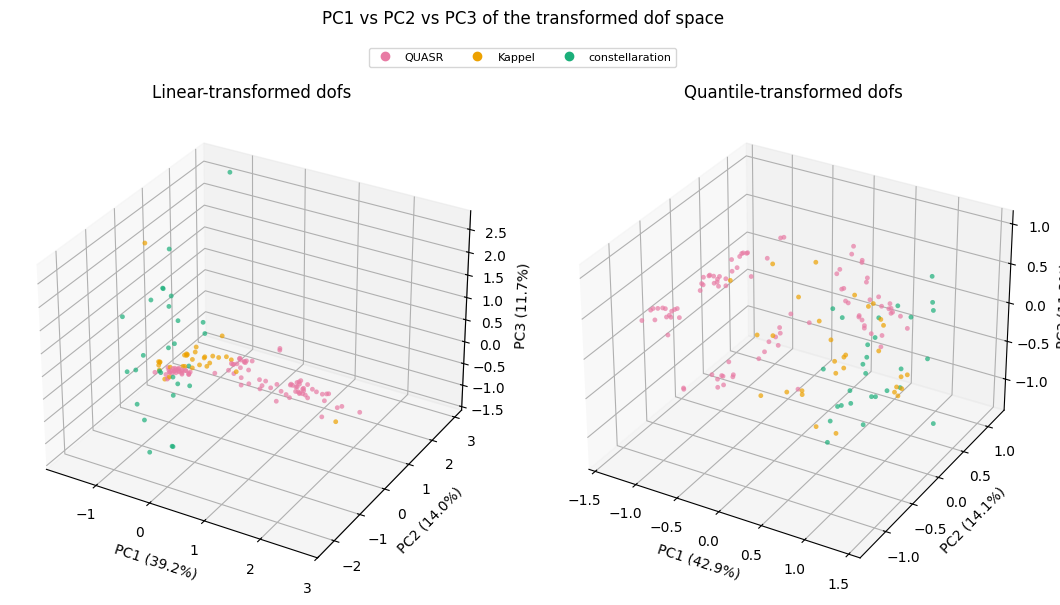

In [46]:
pc_linear = pca_linear.transform(linear_transformed_all)
pc_quantile = pca_quantile.transform(quantile_transformed_all)

fig = plt.figure(figsize=(11, 5.5))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.scatter(pc_linear[:, 0], pc_linear[:, 1], pc_linear[:, 2], c=point_colors, s=12, alpha=0.7, linewidths=0)
ax0.set_title("Linear-transformed dofs")
ax0.set_xlabel(f"PC1 ({pca_linear.explained_variance_ratio_[0] * 100:.1f}%)")
ax0.set_ylabel(f"PC2 ({pca_linear.explained_variance_ratio_[1] * 100:.1f}%)")
ax0.set_zlabel(f"PC3 ({pca_linear.explained_variance_ratio_[2] * 100:.1f}%)")

ax1 = fig.add_subplot(1, 2, 2, projection="3d")
ax1.scatter(pc_quantile[:, 0], pc_quantile[:, 1], pc_quantile[:, 2], c=point_colors, s=12, alpha=0.7, linewidths=0)
ax1.set_title("Quantile-transformed dofs")
ax1.set_xlabel(f"PC1 ({pca_quantile.explained_variance_ratio_[0] * 100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca_quantile.explained_variance_ratio_[1] * 100:.1f}%)")
ax1.set_zlabel(f"PC3 ({pca_quantile.explained_variance_ratio_[2] * 100:.1f}%)")

handles = [
    plt.Line2D([], [], marker="o", linestyle="", color=c, label=weight_to_source.get(w, f"weight={w:.4f}"))
    for w, c in weight_colors.items()
]
fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 1.02), fontsize=8)
fig.suptitle("PC1 vs PC2 vs PC3 of the transformed dof space", y=1.08)
plt.tight_layout()
plt.show()

### Does weighting the PCA itself actually matter?

Same idea as above, but this time the PCA is computed with `sample_weight=weights` via `weightedpca.WeightedPCA`
(the same class `SurfaceWeightedPCA` uses), so the mean and covariance are estimated with each configuration counted
according to its source weight rather than counted once regardless of source. This isolates whether the unweighted
comparison above was actually being skewed by QUASR's disproportionate share of the raw rows.

In [44]:
from weightedpca import WeightedPCA

pca_linear_w = WeightedPCA()
pca_linear_w.fit(linear_transformed_all, weights=weights)
pca_quantile_w = WeightedPCA()
pca_quantile_w.fit(quantile_transformed_all, weights=weights)

cum_linear_w = np.cumsum(pca_linear_w.explained_variance_ratio_)
cum_quantile_w = np.cumsum(pca_quantile_w.explained_variance_ratio_)

n90_linear_w = np.searchsorted(cum_linear_w, 0.90) + 1
n90_quantile_w = np.searchsorted(cum_quantile_w, 0.90) + 1

print(f"Linear-transformed dof space,   weighted PCA: {n90_linear_w}/{n_modes} components for 90% variance"
      f"  (unweighted was {n90_linear})")
print(f"Quantile-transformed dof space, weighted PCA: {n90_quantile_w}/{n_modes} components for 90% variance"
      f"  (unweighted was {n90_quantile})")

Linear-transformed dof space,   weighted PCA: 9/23 components for 90% variance  (unweighted was 8)
Quantile-transformed dof space, weighted PCA: 10/23 components for 90% variance  (unweighted was 9)


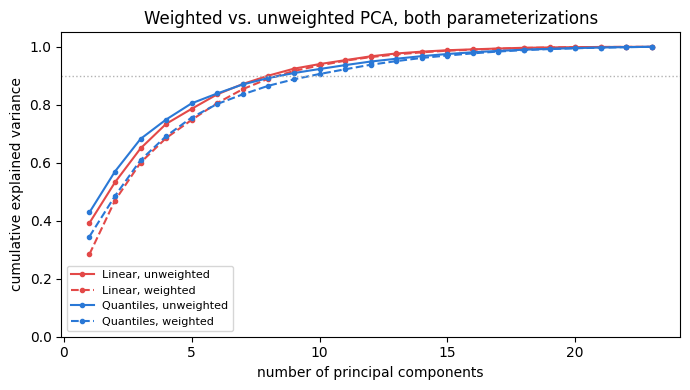

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(components, cum_linear, color=RED, marker="o", markersize=3, label="Linear, unweighted")
ax.plot(components, cum_linear_w, color=RED, marker="o", markersize=3, linestyle="--", label="Linear, weighted")
ax.plot(components, cum_quantile, color=BLUE, marker="o", markersize=3, label="Quantiles, unweighted")
ax.plot(components, cum_quantile_w, color=BLUE, marker="o", markersize=3, linestyle="--", label="Quantiles, weighted")
ax.axhline(0.9, color="0.7", lw=1, linestyle=":")
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
ax.set_title("Weighted vs. unweighted PCA, both parameterizations")
plt.tight_layout()
plt.show()